# Pan-Cancer Master Regulator Analysis

### Inputs / Parameters
*This section documents explicit inputs for reproducibility.*
- **Data files:** `output/[cancer]_results/primary_vs_metastasis_[cancer]_results_DE_metabolic_targets.csv`

### Goal
Determine the top transcription factors that are master transcriptional regulators of the dynamically computed pan-cancer metastatic metabolic signature.

### Purpose
To identify if the pan-cancer conserved metabolic targets share common transcriptional regulation.
**Interpretation Guide:** If a specific transcription factor (e.g. NR1D2, MYC, etc.) is highly enriched as a regulator for these genes, it provides strong evidence to hypothesize that it may drive the shared metabolic reprogramming required for metastasis.


In [ ]:
import pandas as pd
import os
import json
import requests
import matplotlib.pyplot as plt
import seaborn as sns

import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

try:
    BASE_DIR = os.path.abspath(os.path.dirname(__file__))
    if os.path.basename(BASE_DIR) == 'scripts':
        BASE_DIR = os.path.dirname(BASE_DIR)
except NameError:
    BASE_DIR = os.path.abspath('.')
    if os.path.basename(BASE_DIR) == 'scripts':
        BASE_DIR = os.path.dirname(BASE_DIR)

OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'master_regulator_results')
os.makedirs(RESULTS_DIR, exist_ok=True)

import sys
import os

sys.path.append(os.path.abspath(".."))
from pan_cancer_config import CANCERS_TO_RUN as CANCERS
ENRICHR_LIBRARIES = [
    'ChEA_2022',
    'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X',
    'TRRUST_Transcription_Factors_2019'
]


In [ ]:
TARGET_GENES = ['EPOR', 'CD46', 'SLC2A6', 'VTN', 'ADAM10', 'GCNT1', 'KCNN2', 'GBE1', 'SLC11A2', 'CERT1', 'S1PR1', 'GCLM', 'LTB4R', 'GABRG3', 'P2RY8', 'ADORA3', 'CYP19A1', 'ADRA2B', 'OCLN', 'CXADR', 'CXCR1', 'C1GALT1', 'AUH', 'SLC1A2', 'CSF3R', 'ITGAM', 'SLC46A1', 'FCN1', 'ITGB2', 'GFRA2', 'AMDHD1', 'EPHB1', 'TNFRSF21', 'CUL5', 'CCR9', 'SRP54', 'AGER', 'ITGA4', 'CD3G', 'ACVR2B', 'CD79A', 'ACACA', 'FADS2', 'SIRPB1', 'P2RY14', 'PLXNA4', 'CD244', 'DGKG', 'PDE3B', 'IL1R1', 'JAML', 'IL1RAP', 'FCER2', 'NR2F1', 'ESR1', 'GCNT4', 'DGAT2', 'ASGR1', 'GLS', 'DGKA', 'CR2', 'ABCB5', 'NMUR1', 'PLCB1', 'ITGAL', 'SLC2A12', 'CD247', 'NPFFR2', 'ACSL4', 'IL17RA', 'ANXA1', 'LILRB1', 'ACKR3', 'GALNT1', 'DGKD', 'HLA-C', 'MTMR1', 'CD1D', 'AMN', 'SCD5', 'CYP2E1', 'ESRRG', 'GPC5', 'GRM1', 'IFNLR1', 'SELL', 'GJA5', 'IL7R', 'CD48', 'SLC15A1', 'SPTLC1', 'NR1D2', 'NCOA3', 'RXRA', 'TLR10', 'SLC22A1', 'CD36', 'TSHR', 'TRPM8', 'CYSLTR2', 'IL13RA2', 'TGFBR2', 'CDH23', 'SPN', 'HK3', 'CNR2', 'TRPM7', 'SLC6A3', 'PLCL1', 'DBT', 'THRB', 'KLRG1', 'CNDP1', 'CYP1B1', 'ACVR1B', 'SULT1A1', 'FZD6', 'PGS1', 'LGSN', 'OGDH', 'ERAP1', 'SLC16A6', 'SLC16A7', 'CYSLTR1', 'CHRNA6', 'CELSR1']
print(f"Dynamically resolved {len(TARGET_GENES)} pan-cancer upregulated metabolic genes.")
print(f"Genes investigated: {TARGET_GENES}")

# Run enrichment analysis
add_list_url = 'https://maayanlab.cloud/Enrichr/addList'
payload = {
    'list': (None, '\n'.join(TARGET_GENES)),
    'description': (None, 'Pan-Cancer Metabolic Targets')
}
response = requests.post(add_list_url, files=payload)
if not response.ok:
    raise Exception('Error analyzing gene list with Enrichr')

data = json.loads(response.text)
user_list_id = data['userListId']

all_results = []
for lib in ENRICHR_LIBRARIES:
    print(f"Querying Enrichr library: {lib}...")
    enrich_url = f'https://maayanlab.cloud/Enrichr/enrich?userListId={user_list_id}&backgroundType={lib}'
    res = requests.get(enrich_url)
    if not res.ok:
        print(f"Error fetching {lib}")
        continue
        
    results = json.loads(res.text)[lib]
    for row in results:
        term = row[1]
        pval = row[2]
        adj_pval = row[6]
        combined_score = row[4]
        overlap = row[5]
        
        tf_name = term.split('_')[0].split(' ')[0].upper()
        
        all_results.append({
            'Library': lib,
            'Term': term,
            'Transcription Factor': tf_name,
            'P-value': pval,
            'Adjusted P-value': adj_pval,
            'Combined Score': combined_score,
            'Overlapping Genes': ','.join(overlap)
        })
        
df_enrich = pd.DataFrame(all_results)
csv_path = os.path.join(RESULTS_DIR, 'tf_enrichment_results.csv')
df_enrich.to_csv(csv_path, index=False)
print(f"Saved TF enrichment results to {csv_path}\n")

display(df_enrich.head(10))


Dynamically resolved 126 pan-cancer upregulated metabolic genes.
Genes investigated: ['EPOR', 'CD46', 'SLC2A6', 'VTN', 'ADAM10', 'GCNT1', 'KCNN2', 'GBE1', 'SLC11A2', 'CERT1', 'S1PR1', 'GCLM', 'LTB4R', 'GABRG3', 'P2RY8', 'ADORA3', 'CYP19A1', 'ADRA2B', 'OCLN', 'CXADR', 'CXCR1', 'C1GALT1', 'AUH', 'SLC1A2', 'CSF3R', 'ITGAM', 'SLC46A1', 'FCN1', 'ITGB2', 'GFRA2', 'AMDHD1', 'EPHB1', 'TNFRSF21', 'CUL5', 'CCR9', 'SRP54', 'AGER', 'ITGA4', 'CD3G', 'ACVR2B', 'CD79A', 'ACACA', 'FADS2', 'SIRPB1', 'P2RY14', 'PLXNA4', 'CD244', 'DGKG', 'PDE3B', 'IL1R1', 'JAML', 'IL1RAP', 'FCER2', 'NR2F1', 'ESR1', 'GCNT4', 'DGAT2', 'ASGR1', 'GLS', 'DGKA', 'CR2', 'ABCB5', 'NMUR1', 'PLCB1', 'ITGAL', 'SLC2A12', 'CD247', 'NPFFR2', 'ACSL4', 'IL17RA', 'ANXA1', 'LILRB1', 'ACKR3', 'GALNT1', 'DGKD', 'HLA-C', 'MTMR1', 'CD1D', 'AMN', 'SCD5', 'CYP2E1', 'ESRRG', 'GPC5', 'GRM1', 'IFNLR1', 'SELL', 'GJA5', 'IL7R', 'CD48', 'SLC15A1', 'SPTLC1', 'NR1D2', 'NCOA3', 'RXRA', 'TLR10', 'SLC22A1', 'CD36', 'TSHR', 'TRPM8', 'CYSLTR2', 'IL13RA2', '

,Library,Term,Transcription Factor,P-value,Adjusted P-value,Combined Score,Overlapping Genes
0,ChEA_2022,STAT3 23295773 ChIP-Seq U87 Human,STAT3,1.607449e-07,0.000115,46.631765,"DGKG,DGKD,THRB,GBE1,SLC22A1,PDE3B,ABCB5,IL1RAP..."
1,ChEA_2022,RUNX 20019798 ChIP-Seq JUKART Human,RUNX,6.915245e-07,0.000247,75.827296,"CR2,ITGA4,PLCL1,DGKA,ERAP1,CD1D,TGFBR2,SELL,AU..."
2,ChEA_2022,IRF8 27001747 Chip-Seq BMDM Mouse,IRF8,1.884186e-06,0.000448,42.783419,"DGKG,SLC46A1,CSF3R,DGKD,ITGAM,SLC1A2,ITGAL,ACV..."
3,ChEA_2022,TCF4 23295773 ChIP-Seq U87 Human,TCF4,6.895741e-06,0.000780,29.492355,"DGKG,GBE1,PDE3B,ABCB5,SLC1A2,IL1RAP,ACVR1B,CND..."
4,ChEA_2022,PPAR 26484153 Chip-Seq NCI-H1993 Human,PPAR,7.198085e-06,0.000780,43.026508,"ANXA1,CXADR,THRB,IL1R1,C1GALT1,ACSL4,NR1D2,IL1..."
5,ChEA_2022,TAL1 30185409 ChIP-Seq HPC Mouse BoneMarrow Le...,TAL1,7.890110e-06,0.000780,32.058641,"THRB,SLC22A1,ABCB5,GCNT1,SLC1A2,SLC6A3,ACACA,G..."
6,ChEA_2022,NFE2L2 20460467 ChIP-Seq MEFs Mouse,NFE2L2,8.735883e-06,0.000780,43.343039,"CR2,ANXA1,GBE1,FZD6,C1GALT1,ITGB2,GCNT1,NR1D2,..."
7,ChEA_2022,NRF2 20460467 ChIP-Seq MEFs Mouse,NRF2,8.735883e-06,0.000780,43.343039,"CR2,ANXA1,GBE1,FZD6,C1GALT1,ITGB2,GCNT1,NR1D2,..."
8,ChEA_2022,SMARCD1 25818293 ChIP-Seq ESCs Mouse,SMARCD1,1.501589e-05,0.001191,31.746881,"DGKG,DGKD,THRB,ITGAM,IL1RAP,CNDP1,GRM1,CYSLTR2..."
9,ChEA_2022,CRX 20693478 ChIP-Seq RETINA Mouse,CRX,1.765322e-05,0.001237,32.288214,"CR2,DGKD,IL1R1,PLCL1,DGKA,SLC2A12,ESRRG,ESR1,A..."


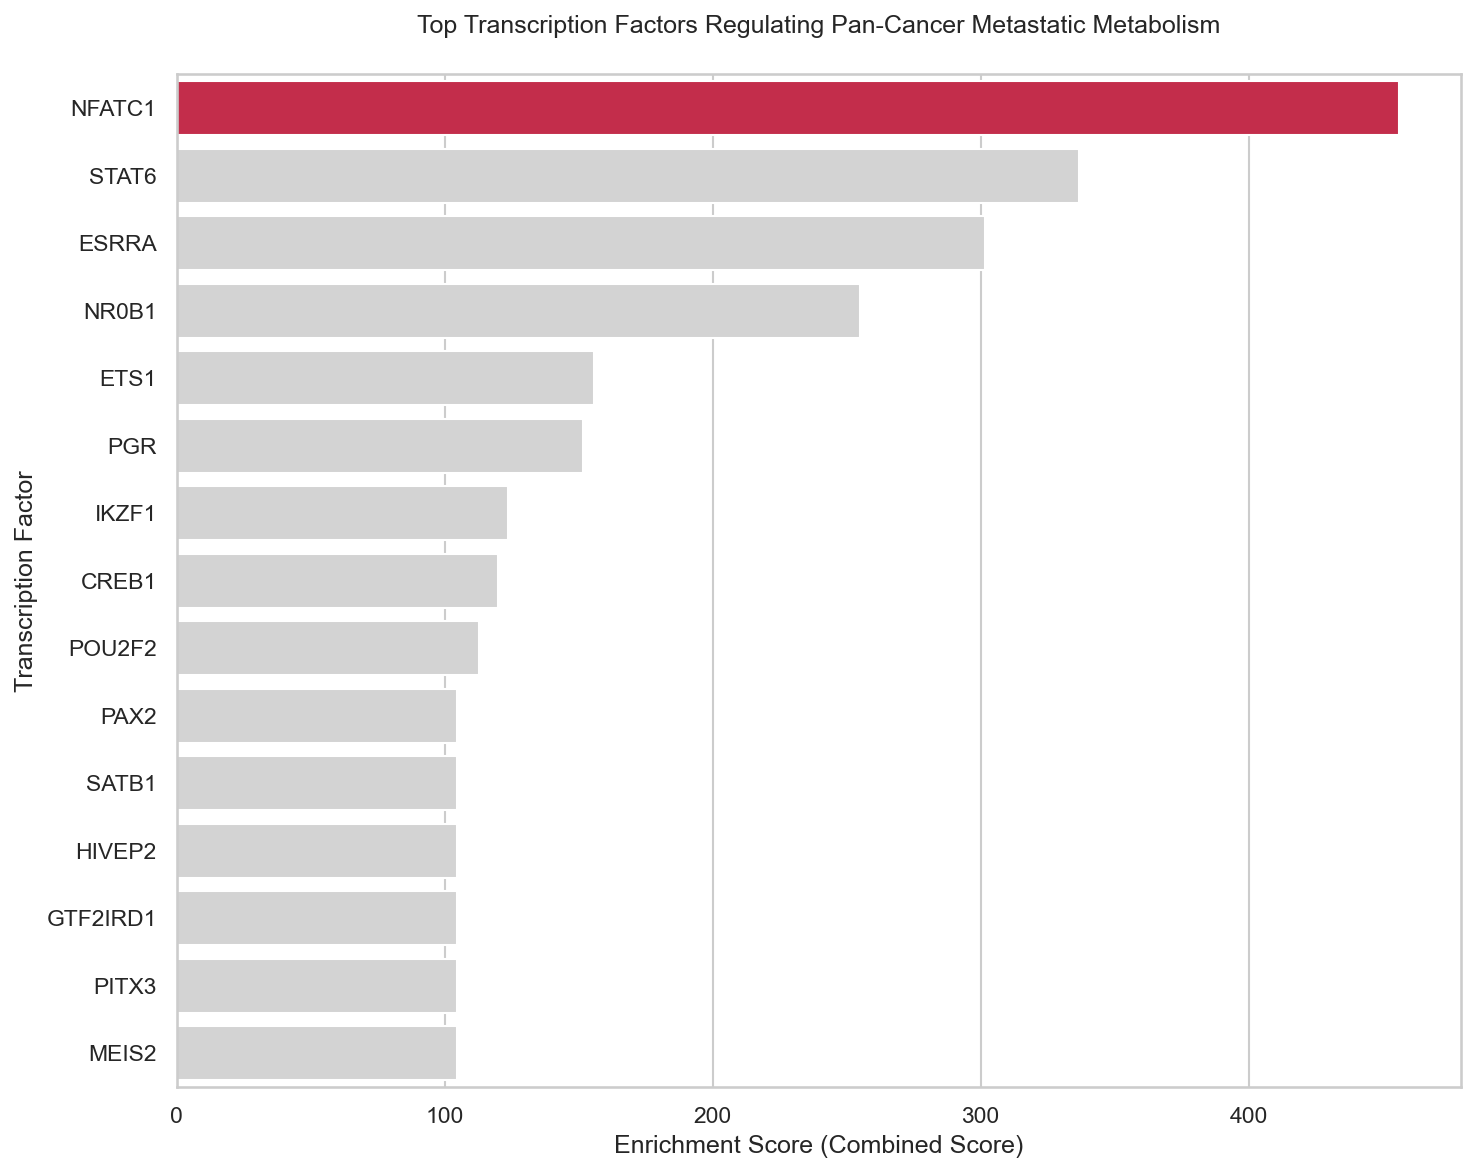

In [ ]:
top_tfs = df_enrich.sort_values('Combined Score', ascending=False).drop_duplicates(subset=['Transcription Factor']).head(15)

# Dynamically highlight the top transcription factor
if not top_tfs.empty:
    top_tf = top_tfs.iloc[0]['Transcription Factor']
    palette = ['crimson' if tf == top_tf else 'lightgray' for tf in top_tfs['Transcription Factor']]
else:
    palette = 'lightgray'

plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_tfs, y='Transcription Factor', x='Combined Score',
    palette=palette
)
plt.title('Top Transcription Factors Regulating Pan-Cancer Metastatic Metabolism', pad=20)
plt.xlabel('Enrichment Score (Combined Score)')
plt.ylabel('Transcription Factor')
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, 'top_tfs_barplot.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import subprocess
import sys
import os

notebook_filename = 'master_regulator_analysis.ipynb'
output_base = 'master_regulator_analysis' + '_6MetCan_500k'
output_dir = RESULTS_DIR

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", "--execute", notebook_filename, "--output-dir", output_dir, "--output", output_base]
print("To automatically export to HTML, run the above command in your terminal.")
